# PM100D Power Measurement
Single power measurement using Thorlabs PM100D + S144C integrating sphere.

In [ ]:
print("hello")  # for initial test

hello


In [1]:
import pyvisa
import numpy as np
import os
import time
import matplotlib.pyplot as plt

In [2]:
# Test to find visa address
rm = pyvisa.ResourceManager()
resources = rm.list_resources()
print(resources)

('USB0::0x1313::0x8078::P0034465::INSTR', 'ASRL8::INSTR', 'ASRL9::INSTR', 'ASRL12::INSTR', 'ASRL13::INSTR')


Connected to: Thorlabs,PM100D,P0034465,2.8.1
Wavelength:        1.550000E+03 nm
Averaging count:   50
Auto-range:        1
Low-pass filter:   1
  Reading 1/300: 0.423139 mW, Time 0.08 s
  Reading 2/300: 0.423146 mW, Time 0.11 s
  Reading 3/300: 0.423135 mW, Time 0.14 s
  Reading 4/300: 0.423188 mW, Time 0.19 s
  Reading 5/300: 0.423177 mW, Time 0.24 s
  Reading 6/300: 0.423164 mW, Time 0.29 s
  Reading 7/300: 0.423153 mW, Time 0.34 s
  Reading 8/300: 0.423176 mW, Time 0.37 s
  Reading 9/300: 0.423173 mW, Time 0.40 s
  Reading 10/300: 0.423205 mW, Time 0.44 s
  Reading 11/300: 0.423201 mW, Time 0.49 s
  Reading 12/300: 0.423173 mW, Time 0.54 s
  Reading 13/300: 0.423146 mW, Time 0.59 s
  Reading 14/300: 0.423150 mW, Time 0.64 s
  Reading 15/300: 0.423157 mW, Time 0.67 s
  Reading 16/300: 0.423135 mW, Time 0.70 s
  Reading 17/300: 0.423144 mW, Time 0.74 s
  Reading 18/300: 0.423135 mW, Time 0.79 s
  Reading 19/300: 0.423125 mW, Time 0.84 s
  Reading 20/300: 0.423125 mW, Time 0.89 s
  Rea

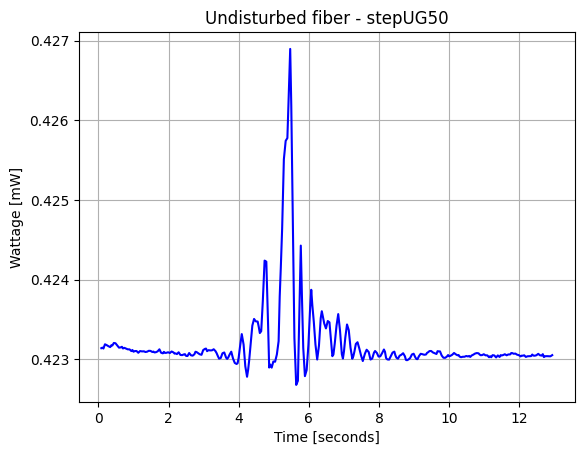

Connection closed.


In [72]:
# Configuration and Varification of the PyVisa querys are writen by Robert Petersen

# Configuration

# Filename (Change manually for each run)
filename = "stepUG50"

# Folder to save data
save_folder = r"C:\Users\leach\OneDrive - Danmarks Tekniske Universitet\4. semester\IoT\Fagprojekt-ML\Saved data\UG_step" # add another folder to seperate types

# Measurement wavelength in nm (set to the same as the laser)
wavelength_nm = 1550

# PM100D VISA address
visa_address = "USB0::0x1313::0x8078::P0034465::INSTR"

# Hardware averaging count (1 to 3000)
hw_averages = 50

# Number of software-side repeat readings to average
sw_repeats = 300

# Check if save folder exists, build file path
os.makedirs(save_folder, exist_ok=True)
file_path = os.path.join(save_folder, filename + ".txt")

# Quick safety check to prevent accidental manual overwrites
if os.path.exists(file_path):
    print(f"WARNING: {file_path} already exists!")
    print("To avoid losing data, change the 'filename' variable at the top and re-run.")
    raise FileExistsError("Execution stopped to prevent overwriting existing data.")

# Connect to PM100D
rm = pyvisa.ResourceManager()
pm = rm.open_resource(visa_address)

print(f"Connected to: {pm.query('*IDN?').strip()}")

# Configure PM100D for maximum precision
pm.write("CONF:POW")                           # Power measurement mode
pm.write(f"CORR:WAV {wavelength_nm}")          # Set calibration wavelength
pm.write(f"SENS:AVER:COUN {hw_averages}")      # Hardware averaging
pm.write("SENS:POW:RANG:AUTO ON")              # Auto-range
pm.write("INP:FILT:LPAS:STAT ON")              # Low-pass filter on

# Verify settings
print(f"Wavelength:        {pm.query('CORR:WAV?').strip()} nm")
print(f"Averaging count:   {pm.query('SENS:AVER:COUN?').strip()}")
print(f"Auto-range:        {pm.query('SENS:POW:RANG:AUTO?').strip()}")
print(f"Low-pass filter:   {pm.query('INP:FILT:LPAS:STAT?').strip()}")

# Take sw_repeats readings and average
readings_W = np.empty(sw_repeats)
timeStamps_W = np.empty(sw_repeats)
startTime = time.time()

for i in range(sw_repeats):
    readings_W[i] = float(pm.query("MEAS:POW?"))
    timeReading = time.time()
    timeStamps_W[i] = timeReading - startTime
    print(f"  Reading {i+1}/{sw_repeats}: {readings_W[i]*1e3:.6f} mW, Time {timeStamps_W[i]:.2f} s")
    time.sleep(0.01) # should maybe be removed, but might give stability

# Find dBm
power_mW = np.mean(readings_W) * 1e3
if power_mW <= 0:
    raise ValueError(f"Measured power is {power_mW:.6f} mW — cannot convert to dBm. Check optical input.")
power_dBm = 10 * np.log10(power_mW)

print(f"\nResult: {power_mW:.6f} mW  /  {power_dBm:.4f} dBm")
print(f"Std of {sw_repeats} readings: {np.std(readings_W)*1e3:.6f} mW")


# Save in txt format
with open(file_path, "w") as f:
    f.write("Power (mW)\tTime (sek)\n")  # Header
    for i in range(sw_repeats):
        f.write(f"{readings_W[i]*1e3:.6f}\t{timeStamps_W[i]:.4f}\n") # Converts W to mW automatically on save to match header
        
    # Add final statistics at the bottom
    f.write(f"\nMean Power (dBm):\t{power_dBm:.4f}\n")
    f.write(f"Mean Power (mW):\t{power_mW:.6f}\n")

print(f"\n>>> Data successfully saved to: {file_path} <<<")


# Plot to visualize as sanity check, in case something went wrong and the file should be deleted.
# Passes time array as X, and mW array as Y
plt.plot(timeStamps_W, readings_W * 1e3, color='b') 
plt.xlabel("Time [seconds]")
plt.ylabel("Wattage [mW]")
plt.title(f"Undisturbed fiber - {filename}")
plt.grid(True)
plt.show()

# Close connection
pm.close()
rm.close()
print("Connection closed.")